# Inference-Time Scaling for Small Local LLM Reasoning

This notebook is the reproducible analysis companion for `reports/research_report.md`. It compares the `v1` prototype results against the `v2` GSM8K benchmark runs, with `results/v2_qwen_gsm8k_50` treated as the main benchmark result.

The emphasis is research interpretation: accuracy, token cost, latency, and failure modes, not just a single leaderboard number.


## Decisions Reflected In This Analysis

- `v1` is treated as a prototype benchmark using hand-authored tasks.
- `v2` is treated as the benchmark upgrade using GSM8K subsets.
- The final free path uses local Hugging Face `transformers` inference with `Qwen/Qwen2.5-0.5B-Instruct`.
- Hosted Hugging Face provider routing was explored, but model/provider availability blocked the free hosted path.
- Final-answer-only prompting and first-line extraction were adopted after observing answer-plus-explanation outputs.
- Strategy names are preserved for comparability, even though visible chain-of-thought is no longer requested in the current prompt code.


In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..").resolve() if Path.cwd().name == "evaluation" else Path(".").resolve()
RESULTS = ROOT / "results"
DATA = ROOT / "data" / "benchmarks"

V1_FILES = {
    "baseline": RESULTS / "baseline_api_results.csv",
    "adaptive": RESULTS / "adaptive_results.csv",
    "chain_of_thought": RESULTS / "cot_results.csv",
    "self_consistency": RESULTS / "self_consistency_results.csv",
}

V2_50 = RESULTS / "v2_qwen_gsm8k_50"
V2_10 = RESULTS / "v2_qwen_gsm8k_10"

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Load Result Summaries

In [2]:
def load_summary(path: Path) -> dict:
    payload = json.loads(path.read_text())
    return {
        "file": path.name,
        "strategy": path.name.replace("_summary.json", "").split("_")[-1],
        "metadata": payload["metadata"],
        **payload["summary"],
    }


def load_run_summaries(run_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(run_dir.glob("*_summary.json")):
        payload = json.loads(path.read_text())
        strategy = payload["metadata"].get("strategy") or path.stem.replace("_summary", "")
        rows.append({
            "strategy": strategy,
            "dataset": payload["metadata"]["experiment"]["dataset_name"],
            "model": payload["metadata"]["runtime"].get("model_name"),
            "backend": payload["metadata"]["runtime"].get("backend"),
            **payload["summary"],
        })
    return pd.DataFrame(rows)

v2_50_summary = load_run_summaries(V2_50)
v2_10_summary = load_run_summaries(V2_10)

cols = ["strategy", "num_examples", "accuracy", "invalid_output_rate", "parse_error_rate", "avg_total_tokens", "total_tokens", "avg_latency_seconds", "accuracy_per_1k_tokens"]
v2_50_summary[cols].sort_values("strategy")

,strategy,num_examples,accuracy,invalid_output_rate,parse_error_rate,avg_total_tokens,total_tokens,avg_latency_seconds,accuracy_per_1k_tokens
0,adaptive,50,0.06,0.000000,0.0,109.720000,5486,0.777160,0.010937
1,baseline,50,0.06,0.000000,0.0,181.720000,9086,3.058723,0.006604
2,chain_of_thought,300,0.05,0.006667,0.0,244.553333,73366,4.647965,0.000682
3,self_consistency,100,0.05,0.000000,0.0,770.880000,77088,13.413515,0.000649


## v1 Prototype Summary

The `v1` results are useful as a prototype comparison. They should not be interpreted as benchmark-grade evidence because the tasks are small and hand-authored.

In [3]:
def load_v1_summary() -> pd.DataFrame:
    rows = []
    baseline = pd.read_csv(V1_FILES["baseline"])
    rows.append({
        "strategy": "baseline",
        "accuracy": baseline["correct"].astype(bool).mean(),
        "avg_tokens": baseline["tokens"].mean(),
        "total_tokens": baseline["tokens"].sum(),
        "rows": len(baseline),
    })

    adaptive = pd.read_csv(V1_FILES["adaptive"])
    rows.append({
        "strategy": "adaptive",
        "accuracy": adaptive["correct"].astype(bool).mean(),
        "avg_tokens": adaptive["tokens_used"].mean(),
        "total_tokens": adaptive["tokens_used"].sum(),
        "rows": len(adaptive),
    })

    cot = pd.read_csv(V1_FILES["chain_of_thought"])
    rows.append({
        "strategy": "chain_of_thought_overall",
        "accuracy": cot["correct"].astype(bool).mean(),
        "avg_tokens": cot["budget"].mean(),
        "total_tokens": cot["budget"].sum(),
        "rows": len(cot),
    })

    sc = pd.read_csv(V1_FILES["self_consistency"])
    rows.append({
        "strategy": "self_consistency",
        "accuracy": sc["correct"].astype(bool).mean(),
        "avg_tokens": None,
        "total_tokens": None,
        "rows": len(sc),
    })
    return pd.DataFrame(rows)

v1_summary = load_v1_summary()
v1_summary

,strategy,accuracy,avg_tokens,total_tokens,rows
0,baseline,0.480000,50.000000,2500.0,50
1,adaptive,0.580000,94.000000,4700.0,50
2,chain_of_thought_overall,0.440000,116.666667,35000.0,300
3,self_consistency,0.126667,NaN,NaN,150


In [4]:
cot_v1 = pd.read_csv(V1_FILES["chain_of_thought"])
(cot_v1.groupby(["strategy", "budget"])["correct"]
 .mean()
 .reset_index()
 .pivot(index="budget", columns="strategy", values="correct"))

strategy,cot,cot_5
budget,,
50,0.30,0.22
100,0.62,0.26
200,0.82,0.42


## Headline v2 Benchmark Results

The 50-question GSM8K subset is the main result. Accuracy is low across all strategies, which is itself a useful finding: extra inference-time compute did not reliably compensate for the limitations of a 0.5B model on multi-step arithmetic.


In [5]:
display_cols = {
    "strategy": "Strategy",
    "num_examples": "Rows",
    "accuracy": "Accuracy",
    "invalid_output_rate": "Invalid Rate",
    "parse_error_rate": "Parse Error Rate",
    "avg_total_tokens": "Avg Tokens",
    "total_tokens": "Total Tokens",
    "avg_latency_seconds": "Avg Latency (s)",
    "accuracy_per_1k_tokens": "Accuracy / 1k Tokens",
}

headline = v2_50_summary[list(display_cols)].rename(columns=display_cols).copy()
headline["Accuracy"] = headline["Accuracy"].round(3)
headline["Invalid Rate"] = headline["Invalid Rate"].round(3)
headline["Parse Error Rate"] = headline["Parse Error Rate"].round(3)
headline["Avg Tokens"] = headline["Avg Tokens"].round(2)
headline["Avg Latency (s)"] = headline["Avg Latency (s)"].round(2)
headline["Accuracy / 1k Tokens"] = headline["Accuracy / 1k Tokens"].round(4)
headline.sort_values("Strategy")

,Strategy,Rows,Accuracy,Invalid Rate,Parse Error Rate,Avg Tokens,Total Tokens,Avg Latency (s),Accuracy / 1k Tokens
0,adaptive,50,0.06,0.000,0.0,109.72,5486,0.78,0.0109
1,baseline,50,0.06,0.000,0.0,181.72,9086,3.06,0.0066
2,chain_of_thought,300,0.05,0.007,0.0,244.55,73366,4.65,0.0007
3,self_consistency,100,0.05,0.000,0.0,770.88,77088,13.41,0.0006


## Accuracy, Token Cost, And Latency

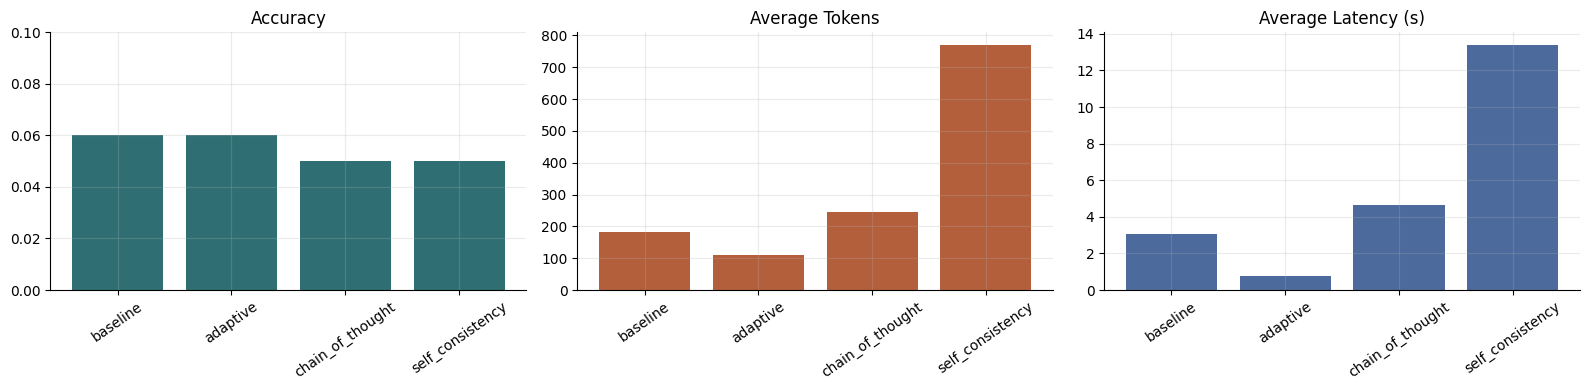

In [6]:
plot_df = v2_50_summary.copy()
order = ["baseline", "adaptive", "chain_of_thought", "self_consistency"]
plot_df["strategy"] = pd.Categorical(plot_df["strategy"], categories=order, ordered=True)
plot_df = plot_df.sort_values("strategy")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(plot_df["strategy"].astype(str), plot_df["accuracy"], color="#2f6f73")
axes[0].set_title("Accuracy")
axes[0].set_ylim(0, max(0.1, plot_df["accuracy"].max() * 1.3))
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(plot_df["strategy"].astype(str), plot_df["avg_total_tokens"], color="#b45f3c")
axes[1].set_title("Average Tokens")
axes[1].tick_params(axis="x", rotation=35)

axes[2].bar(plot_df["strategy"].astype(str), plot_df["avg_latency_seconds"], color="#4c6a9c")
axes[2].set_title("Average Latency (s)")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

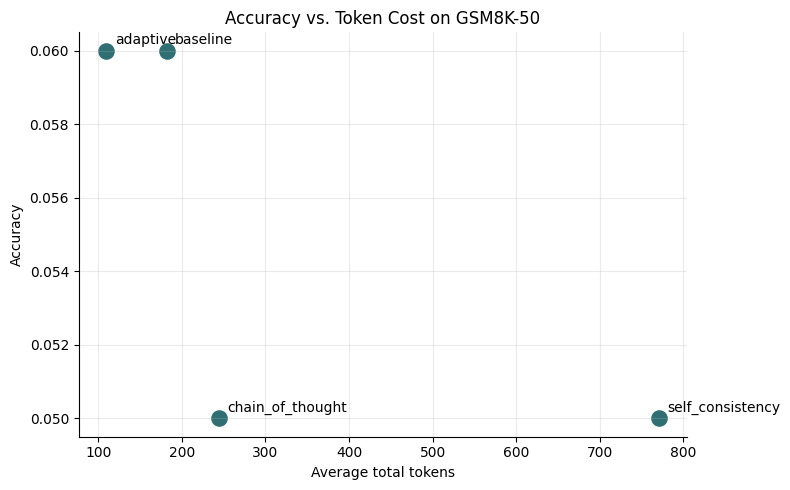

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["avg_total_tokens"], plot_df["accuracy"], s=120, color="#2f6f73")
for _, row in plot_df.iterrows():
    ax.annotate(row["strategy"], (row["avg_total_tokens"], row["accuracy"]), xytext=(6, 5), textcoords="offset points")
ax.set_xlabel("Average total tokens")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. Token Cost on GSM8K-50")
plt.tight_layout()
plt.show()

## Budget Sweep Analysis

In [8]:
cot_v2 = pd.read_csv(V2_50 / "v2_qwen_gsm8k_50_chain_of_thought.csv")
cot_budget = (cot_v2.groupby(["prompt_variant", "budget"])
              .agg(accuracy=("correct", "mean"), rows=("correct", "size"), avg_tokens=("total_tokens", "mean"))
              .reset_index())
cot_budget

,prompt_variant,budget,accuracy,rows,avg_tokens
0,cot,64,0.02,50,160.72
1,cot,128,0.02,50,224.72
2,cot,256,0.06,50,352.72
3,cot_5,64,0.06,50,157.72
4,cot_5,128,0.06,50,221.72
5,cot_5,256,0.08,50,349.72


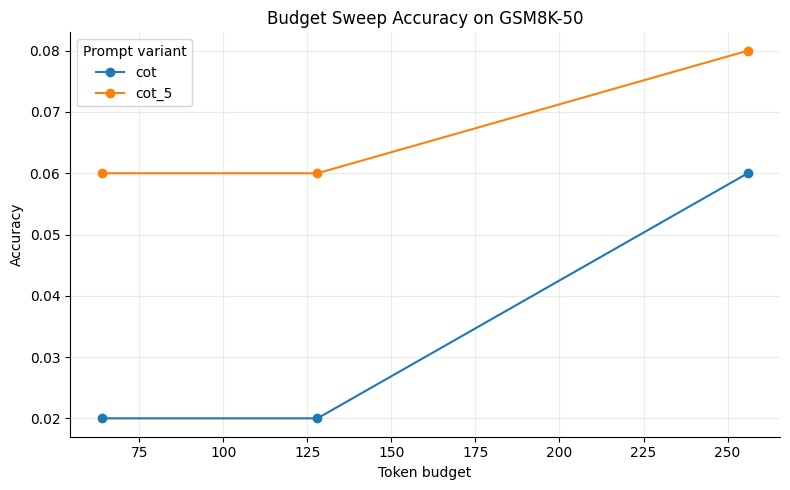

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for variant, subset in cot_budget.groupby("prompt_variant"):
    ax.plot(subset["budget"], subset["accuracy"], marker="o", label=variant)
ax.set_xlabel("Token budget")
ax.set_ylabel("Accuracy")
ax.set_title("Budget Sweep Accuracy on GSM8K-50")
ax.legend(title="Prompt variant")
plt.tight_layout()
plt.show()

## Failure Analysis

The main failure-analysis goal is to distinguish model reasoning failures from output-format failures. The existing run still contains examples where the model outputs an answer followed by explanation text. The current codebase has since been updated to request final answers only and to parse the first clean answer line when no marker is present.

In [10]:
baseline_v2 = pd.read_csv(V2_50 / "v2_qwen_gsm8k_50_baseline.csv")
adaptive_v2 = pd.read_csv(V2_50 / "v2_qwen_gsm8k_50_adaptive.csv")
sc_v2 = pd.read_csv(V2_50 / "v2_qwen_gsm8k_50_self_consistency.csv")

failure_cols = ["id", "question", "answer", "strategy", "raw_output", "parsed_answer", "correct", "error_type", "total_tokens"]
failures = pd.concat([
    baseline_v2.loc[~baseline_v2["correct"].astype(bool), failure_cols].head(5),
    adaptive_v2.loc[~adaptive_v2["correct"].astype(bool), failure_cols].head(5),
], ignore_index=True)
failures

,id,question,answer,strategy,raw_output,parsed_answer,correct,error_type,total_tokens
0,gsm8k-test-588,Jared is trying to increase his typing speed. ...,52,baseline,51\nExplanation: (52 + 5 + 5) / 3 = 51\n\nTask...,51,False,wrong_answer,189
1,gsm8k-test-1214,Jordan has 2 children who wear diapers. Each ...,5,baseline,10\nThe total number of diaper changes is 2 * ...,10,False,wrong_answer,161
2,gsm8k-test-57,A wooden bridge can carry no more than 5000 po...,83,baseline,284\nThe maximum number of boxes that can be l...,284,False,wrong_answer,198
3,gsm8k-test-906,Tim has a box with 7 blue shoe boxes and 9 red...,10,baseline,6\nTo find out how many red and blue shoe boxe...,6,False,wrong_answer,174
4,gsm8k-test-1252,Dominick went to his team's changing room and ...,70,baseline,"60\nTo solve this problem, we need to determin...",60,False,wrong_answer,167
5,gsm8k-test-588,Jared is trying to increase his typing speed. ...,52,adaptive,51\nExplanation: (52 + 5 + 5) / 3 = 51,51,False,wrong_answer,117
6,gsm8k-test-1214,Jordan has 2 children who wear diapers. Each ...,5,adaptive,10\nThe total number of diaper changes is 2 * ...,10,False,wrong_answer,89
7,gsm8k-test-57,A wooden bridge can carry no more than 5000 po...,83,adaptive,284\nThe maximum number of boxes that can be l...,284,False,wrong_answer,126
8,gsm8k-test-906,Tim has a box with 7 blue shoe boxes and 9 red...,10,adaptive,6\nTo find out how many red and blue shoe boxe...,6,False,wrong_answer,102
9,gsm8k-test-1252,Dominick went to his team's changing room and ...,70,adaptive,"60\nTo solve this problem, we need to determin...",60,False,wrong_answer,95


In [11]:
error_frames = []
for path in sorted(V2_50.glob("*.csv")):
    df = pd.read_csv(path)
    strategy = df["strategy"].iloc[0]
    counts = df["error_type"].value_counts(normalize=True).rename("rate").reset_index()
    counts.columns = ["error_type", "rate"]
    counts["strategy"] = strategy
    error_frames.append(counts)
error_rates = pd.concat(error_frames, ignore_index=True)
error_rates

,error_type,rate,strategy
0,wrong_answer,0.940000,adaptive
1,correct,0.060000,adaptive
2,wrong_answer,0.940000,baseline
3,correct,0.060000,baseline
4,wrong_answer,0.943333,chain_of_thought
5,correct,0.050000,chain_of_thought
6,invalid_output,0.006667,chain_of_thought
7,wrong_answer,0.950000,self_consistency
8,correct,0.050000,self_consistency


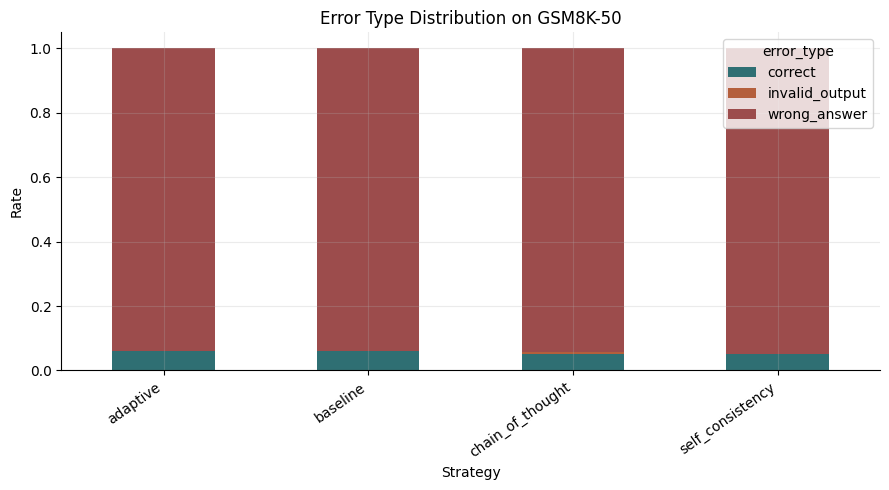

In [12]:
pivot = error_rates.pivot(index="strategy", columns="error_type", values="rate").fillna(0)
pivot.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#2f6f73", "#b45f3c", "#9c4c4c", "#4c6a9c"])
plt.title("Error Type Distribution on GSM8K-50")
plt.xlabel("Strategy")
plt.ylabel("Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Interpretation Notes

The report should avoid overclaiming. The important result is that the evaluation framework makes small-model limits measurable. On GSM8K-50, extra inference-time compute increases cost substantially but does not meaningfully improve accuracy for this 0.5B model.

The best practical interpretation is that inference-time scaling alone is insufficient for this model/task pair. Stronger approaches may require a verifier, calculator/tool use, better confidence estimation, or a larger local model.


## Reproducibility Pointers

Main report: `reports/research_report.md`

Main data:

- `data/benchmarks/prototype_v1.json`
- `data/benchmarks/gsm8k_test_10.json`
- `data/benchmarks/gsm8k_test_50.json`

Main results:

- `results/v2_qwen_gsm8k_50`
- `results/v2_qwen_gsm8k_10`
- legacy `v1` CSV files in `results/`

Recommended final rerun before freezing paper-ready metrics:

```bash
./venv/bin/python run_experiment.py   --backend local_transformers   --model-name Qwen/Qwen2.5-0.5B-Instruct   --dataset-path data/benchmarks/gsm8k_test_50.json   --dataset-name gsm8k_test_50   --experiment-name v2_qwen_gsm8k_50_final_answer_only   --strategies baseline chain_of_thought adaptive self_consistency   --output-dir results/v2_qwen_gsm8k_50_final_answer_only
```
